In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import signal
from scipy.fft import fft, fftfreq, ifft, next_fast_len
import matplotlib.colors as colors
import matplotlib.dates as mdates
import pickle
from sklearn.decomposition import PCA


In [2]:
# Definir o diretório raiz e o prefixo do nome do arquivo
roots = "C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\dados_brutos\\ADCP4_9723\\"
names = "gui04."
# Definir as extensões dos arquivos a serem lidos
extensions = ['sen', 'v1', 'v2', 'v3', 'a1', 'a2', 'a3']
# Ler cada arquivo e armazenar os dados
for ext in extensions:
    arq = np.loadtxt (roots + names + ext)
    globals()[ext] = arq    

In [3]:
time = []
time_II = []
db = sen[:,13] #pressao
depth = ((db*10000)/(1021.32*9.79499))

for i in range(len(sen[:,2])):
    tsh_tempo = datetime.datetime(int(sen[i,2]),
                                 int(sen[i,0]),
                                 int(sen[i,1]),
                                 int(sen[i,3]),
                                 int(sen[i,4]),
                                 int(sen[i,5]))
    tsh_tempo_II = datetime.datetime.timestamp(tsh_tempo)# Converti pra timestamp pra poder interpolar.
    time.append(tsh_tempo)
    time_II.append(tsh_tempo_II)

In [4]:
print(time[6], time[64])

2023-11-28 07:00:00 2023-11-28 16:40:00


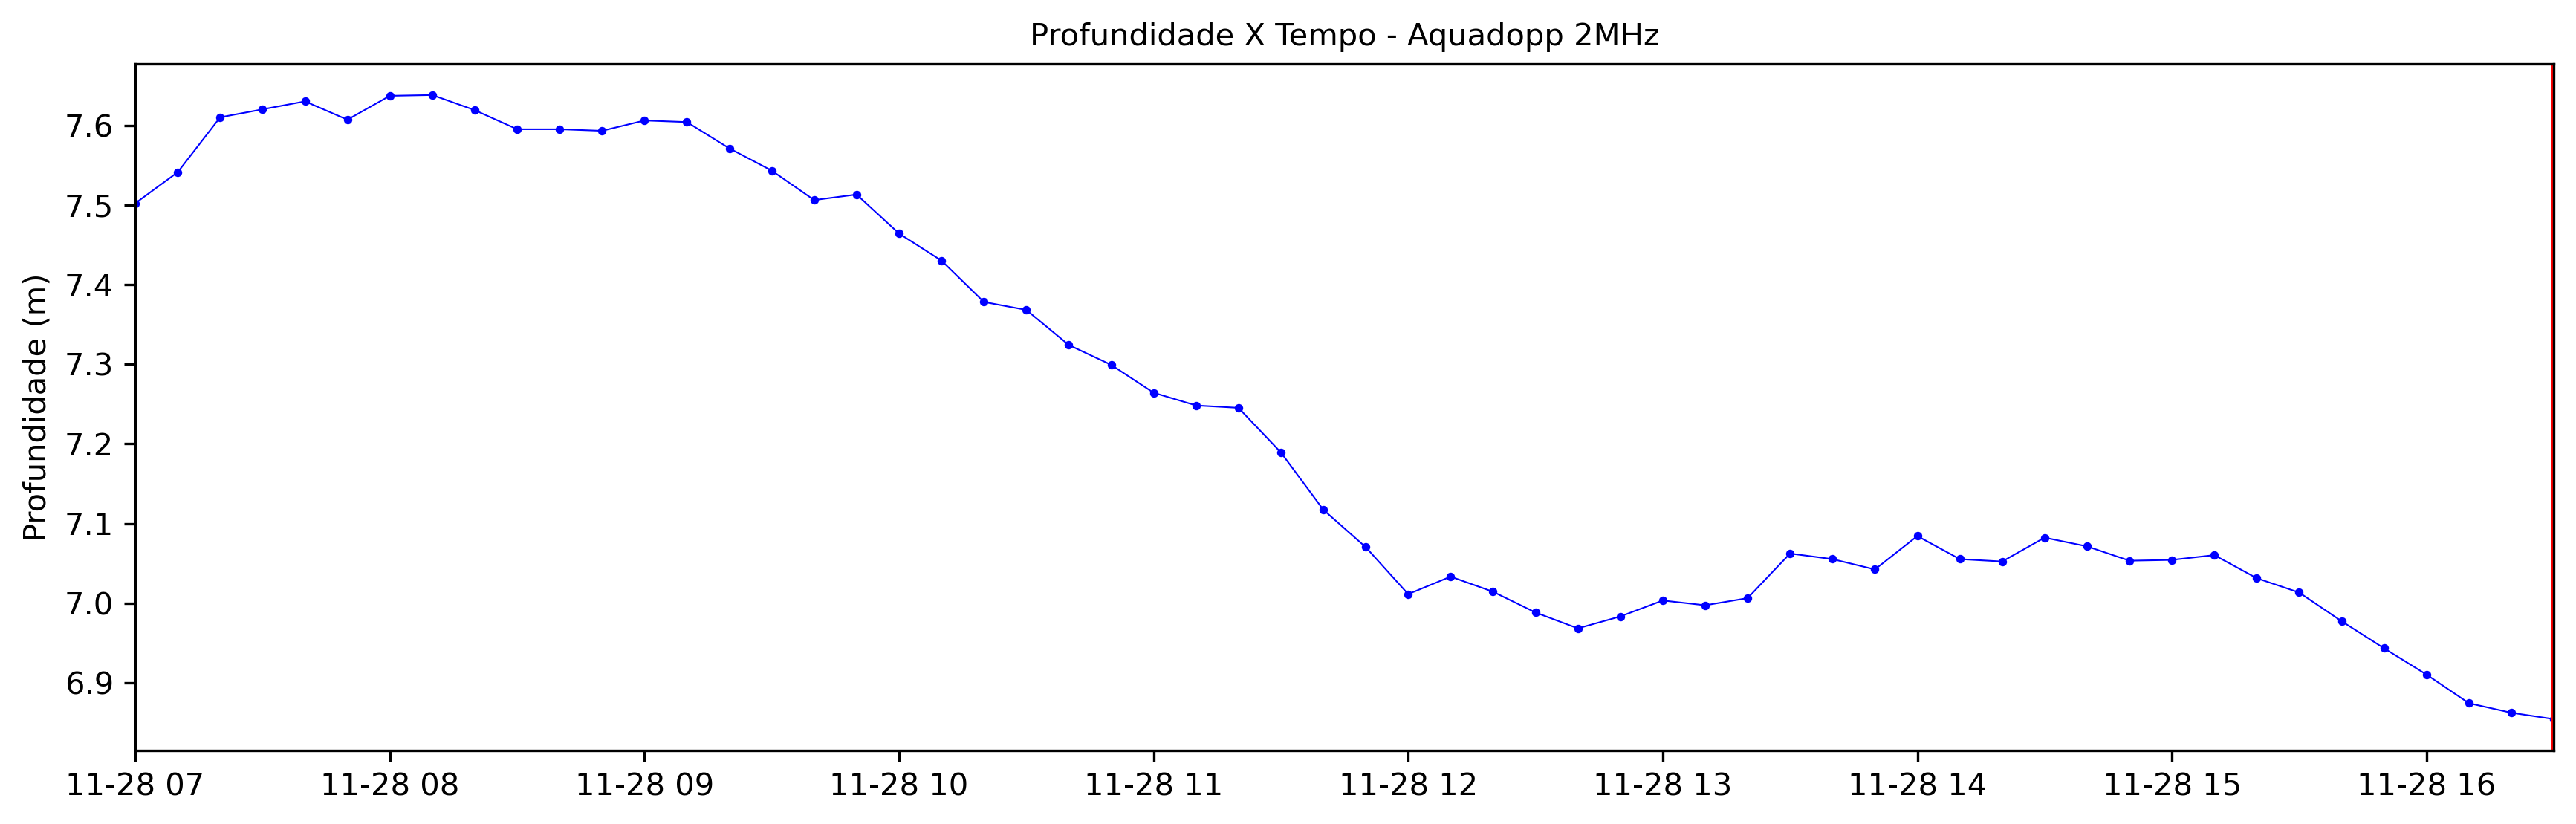

In [5]:
m=6
n=64
fig, ax = plt.subplots(figsize=(14,4), dpi = 300)
ax.scatter(time[m:n], depth[m:n], color  = 'b', linewidth = 0.5, s=5)
ax.plot(time[m:n], depth[m:n], color  = 'b', linewidth = 0.5)
plt.title("Profundidade X Tempo - Aquadopp 2MHz", fontsize=10)
ax.set_ylabel('Profundidade (m)')
ax.set_xlim(np.nanmin(time[m:n]), np.nanmax(time[m:n]))
ax.axvline(x = time[63], color='r')

In [6]:
z = np.arange(0.7, 9.7, 0.3)
amp = (a1[m:n,:] + a2[m:n,:] + a3[m:n,:])/3

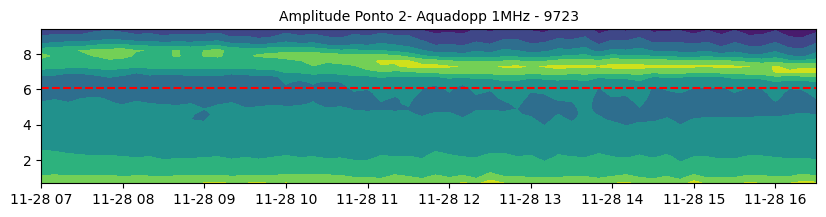

In [7]:
fig, ax = plt.subplots(figsize=(10,2), dpi = 100)
plt.title("Amplitude Ponto 2- Aquadopp 1MHz - 9723", fontsize=10)
ax.contourf(time[m:n], z, amp.T)
ax.axhline(y=z[18], color='r', linestyle='--')

Text(0.5, 0, 'Amplitude (dB)')

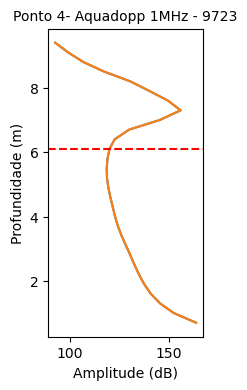

In [8]:
fig, ax = plt.subplots(figsize=(2,4), dpi = 100)
ax.plot(np.nanmean(amp, axis = 0),z)
ax.plot(np.nanmean(amp, axis = 0),z)
plt.axhline(y=z[18], color='r', linestyle='--')
plt.title("Ponto 4- Aquadopp 1MHz - 9723", fontsize=10)

plt.ylabel('Profundidade (m)')
plt.xlabel("Amplitude (dB)")

In [9]:
np.shape(z)

(30,)

In [10]:
amp_cut = np.delete(amp, slice(18,30), axis = 1)
z_cut = np.delete(z, slice(18,30), axis = 0)

v1_cut = np.delete(v1, slice(18,30), axis=1)
v2_cut = np.delete(v2, slice(18,30), axis=1)
v3_cut = np.delete(v3, slice(18,30), axis=1)
a1_cut = np.delete(a1, slice(18,30), axis=1)
a2_cut = np.delete(a2, slice(18,30), axis=1)
a3_cut = np.delete(a3, slice(18,30), axis=1)

Text(0.5, 0, 'Amplitude (dB)')

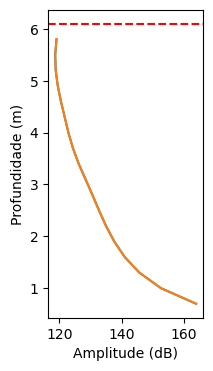

In [11]:
fig, ax = plt.subplots(figsize=(2,4), dpi = 100)
ax.plot(np.nanmean(amp_cut, axis = 0),z_cut)
ax.plot(np.nanmean(amp_cut, axis = 0),z_cut)
plt.axhline(y=z[18], color='r', linestyle='--')
plt.ylabel('Profundidade (m)')
plt.xlabel("Amplitude (dB)")

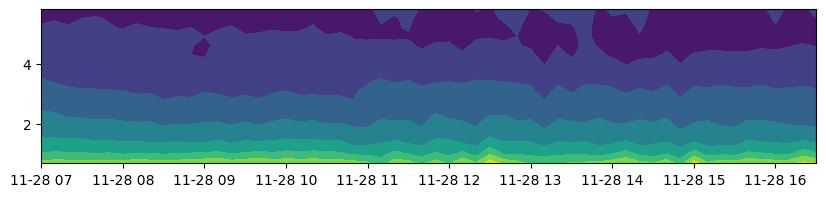

In [12]:
fig, ax = plt.subplots(figsize=(10,2), dpi = 100)
ax.contourf(time[m:n], z_cut, amp_cut.T)

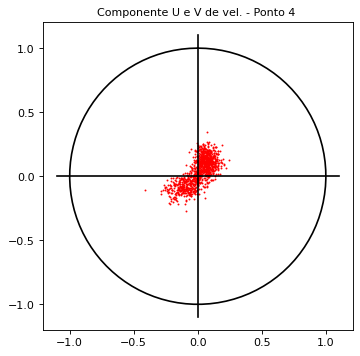

In [13]:
#Comparando os dados de vel. brutos com os dados rotacionados. 
fig, ax = plt.subplots(figsize=(5,5), dpi = 80)
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_y = np.cos(n)
ax.plot(circ_x, circ_y,'k')
ax.plot([0,0], [-1.1, 1.1], 'k')
ax.plot([-1.1, 1.1], [0, 0], 'k')
ax.axis('equal')
plt.title("Componente U e V de vel. - Ponto 4 ", fontsize=10)
ax.scatter(v1_cut[6:64,:],v2_cut[6:64,:],c = 'r', s = 0.5, label = 'Com rotacao')

Ângulo com o norte verdadeiro: 139.87 graus


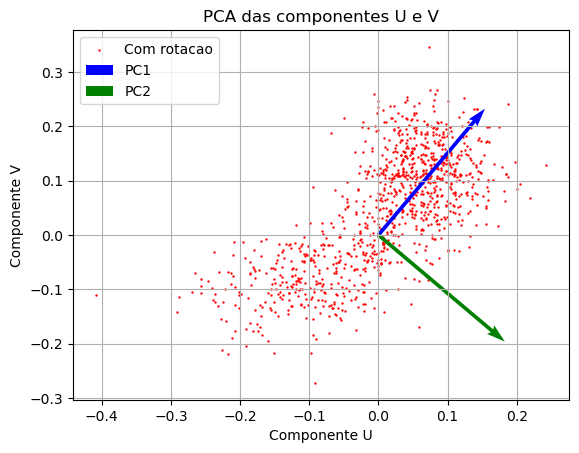

In [14]:
# Supondo que v1_cut e v2_cut são numpy arrays
v1 = v1_cut[6:64,:].flatten()  # Ajuste os índices conforme necessário
v2 = v2_cut[6:64,:].flatten()  # Ajuste os índices conforme necessário

# Organizando os dados para a PCA
data = np.vstack((v1, v2)).T

# Aplicando PCA
pca = PCA(n_components=2)
pca.fit(data)
components = pca.components_

# Componentes principais
pc1 = components[0]
pc2 = components[1]

# Calculando o ângulo entre o primeiro componente principal e o norte verdadeiro (eixo y)
angle_with_north = np.arctan2(pc1[1], pc1[0])  # Em radianos
angle_with_north_deg = np.degrees(angle_with_north) + 90# Convertendo para graus

print(f"Ângulo com o norte verdadeiro: {angle_with_north_deg:.2f} graus")

# Plotando os dados
plt.scatter(v1, v2, c='r', s=0.5, label='Com rotacao')

# Plotando os componentes principais
origin = [0], [0]  # origem
plt.quiver(*origin, *pc1, color='b', scale=3, label='PC1')
plt.quiver(*origin, *pc2, color='g', scale=3, label='PC2')

plt.xlabel('Componente U')
plt.ylabel('Componente V')
plt.legend()
plt.title('PCA das componentes U e V')
plt.grid(True)
plt.show()

In [15]:
#Rotacionando os dados de vel. em 29 graus.
M = np.sqrt(v1_cut[6:64,:]**2+v2_cut[6:64,:]**2)
UV_dir = np.arctan2(v2_cut[6:64,:]/M, v1_cut[6:64,:]/M) 
UV_dir_degrees = np.rad2deg(UV_dir)
UV_dir_degrees[UV_dir_degrees < 0] += 360   

U_spin = np.zeros((len(M), len(z_cut[:])))
V_spin = np.zeros((len(M), len(z_cut[:])))

for i in range(len(z_cut)):
    for j in range(len(M)):
        if (M[j,i] != 0):
            rot_ang = (UV_dir_degrees[j,i]+40.13)%360        
            V_spin[j,i] = M[j,i]*np.cos(np.radians(rot_ang))
            U_spin[j,i] = M[j,i]*np.sin(np.radians(rot_ang))

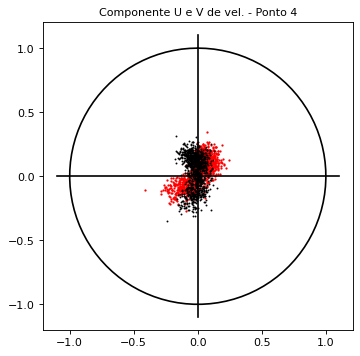

In [16]:
m=6
n=64
#Comparando os dados de vel. brutos com os dados rotacionados. 
fig, ax = plt.subplots(figsize=(5,5), dpi = 80)
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_y = np.cos(n)
ax.plot(circ_x, circ_y,'k')
ax.plot([0,0], [-1.1, 1.1], 'k')
ax.plot([-1.1, 1.1], [0, 0], 'k')
ax.axis('equal')
plt.title("Componente U e V de vel. - Ponto 4", fontsize=10)
ax.scatter(v1_cut[6:64,:],v2_cut[6:64,:],c = 'r', s = 1, label = 'Com rotacao')
ax.scatter(V_spin,U_spin,c = 'k', s = 0.5, label = 'Com rotacao')

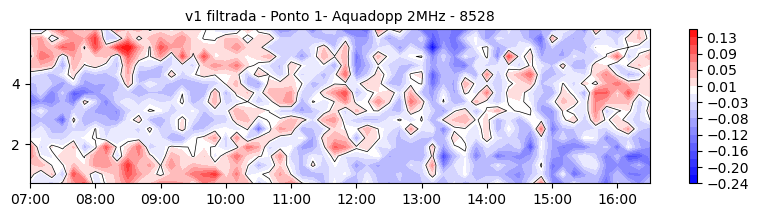

In [17]:
m=6
n=64
divnorm = colors.TwoSlopeNorm(vmin = np.nanmin(V_spin),vcenter = 0, vmax = np.nanmax(V_spin))
myFmt = mdates.DateFormatter('%H:%M')

fig, ax = plt.subplots(figsize=(10,2), dpi = 100)
plt.title("v1 filtrada - Ponto 1- Aquadopp 2MHz - 8528", fontsize=10)
q = ax.contourf(time[m:n], z_cut, V_spin.T, np.round(np.linspace(np.nanmin(V_spin), np.nanmax(V_spin), 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax.contour(time[m:n], z_cut, V_spin.T, levels = [0], colors ='k', linewidths = 0.5, norm = divnorm)
ax.xaxis.set_major_formatter(myFmt)
plt.colorbar(q)

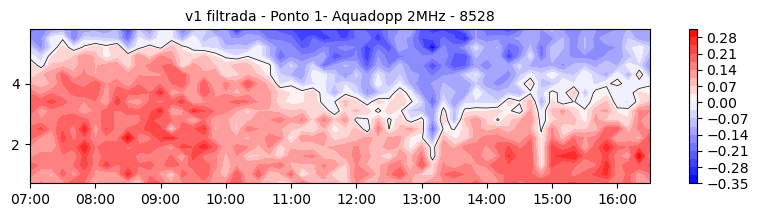

In [18]:
m=6
n=64
divnorm = colors.TwoSlopeNorm(vmin = np.nanmin(U_spin),vcenter = 0, vmax = np.nanmax(U_spin))
myFmt = mdates.DateFormatter('%H:%M')

fig, ax = plt.subplots(figsize=(10,2), dpi = 100)
plt.title("v1 filtrada - Ponto 1- Aquadopp 2MHz - 8528", fontsize=10)
q = ax.contourf(time[m:n], z_cut, U_spin.T, np.round(np.linspace(np.nanmin(U_spin), np.nanmax(U_spin), 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax.contour(time[m:n], z_cut, U_spin.T, levels = [0], colors ='k', linewidths = 0.5, norm = divnorm)
ax.xaxis.set_major_formatter(myFmt)
plt.colorbar(q)

In [19]:
m=6
n=64
dados_adcp4 = np.zeros((3,58,18))
dados_adcp4[0] = U_spin
dados_adcp4[1] = V_spin
dados_adcp4[2] = 0



with open('C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\Processados\\ADCP4_UVSSC_REV.pkl', 'wb') as file:
    pickle.dump(dados_adcp4, file)

with open('C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\Processados\\ADCP4_depth_REV.pkl', 'wb') as file:
    pickle.dump(depth[m:n], file)
    
with open('C:\\Users\\simcosta\\Documents\\doc\\Campo_2023\\Campo_2023\\Processados\\ADCP4_time_REV.pkl', 'wb') as file:
    pickle.dump(time[m:n], file)